# Code here

In [ ]:
# imports
import pandas as pd

#setting column specifications
colspecs = [
    (0, 5),
    (5, 8),
    (8, 15),
    (15, 20),
    (20, 28),
    (28, 36),
    (36, 44),
    (44, 52),
    (52, 60),
    (60, 68),
]


#setting names of columns
names = ["res_id", "res_name", "atom_name", "atom_id", "x", "y", "z", "Vx", "Vy", "Vz"]

#reading data
data = pd.read_fwf(
    "../../data/npt-HK4.gro",
    colspecs=colspecs,
    names=names,
    skiprows=2,
    skipfooter=1,
)

# Problem: after atom id 99999, it reverts back to 0. The following solves this:
for i in data.index:
    if i >= 99999:
        data.at[i,'atom_id'] += 100000

#reading Title, number of atoms and box_dimensions
with open("../../data/npt-HK4.gro", "rb") as f:
    title = f.readline().decode().strip() #First line of .gro file
    num_atoms = f.readline().decode().strip() #Second line of .gro file

    #Last line of file
    f.seek(-2, 2)
    while f.read(1) != b"\n":
        f.seek(-2, 1)
    box_dimensions = f.readline().decode().strip()


print(data.tail())
print(f"Title: {title}")
print(f"Number of atoms: {num_atoms}")
print(f"Box dimensions: {box_dimensions}")

        res_id res_name atom_name  atom_id      x      y      z      Vx  \
126079    1501      HK4       H23   126080  0.953  5.984  1.494 -1.2440   
126080    1501      HK4       C44   126081  0.736  6.009  1.525  0.1513   
126081    1501      HK4       H24   126082  0.707  6.041  1.425  0.3100   
126082    1501      HK4       C45   126083  0.632  5.988  1.615 -0.0110   
126083    1501      HK4       H25   126084  0.542  6.051  1.607 -0.7669   

            Vy      Vz  
126079  0.1068 -0.7226  
126080  0.5200  0.5632  
126081  2.4172  1.1123  
126082 -0.1637  0.2235  
126083 -0.9514  2.2265  
Title: mol only system in water
Number of atoms: 126084
Box dimensions: 11.24798  11.24798  11.24798


## Method 2

### 2-D Case (will update to 3-D later)

In [6]:
# Dependencies
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Matplotlib settings
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 200

In [8]:
# Helper functions

# Finding all neighbor distances algorithm
def find_distances(node: list, x: np.ndarray, y: np.ndarray) -> tuple:
    """
    Find then sort all other nodes distances, alongside their sorted indices, with respect to a given node in a 2D space.
    
    Parameters:
    node (array-like): Coordinates of node [x, y].
    x (np.ndarray)   : x-coordinates of points.
    y (np.ndarray)   : y-coordinates of points.
    
    Returns:
    tuple: Sorted distances and indices of the nearest neighbors.
    """
    # Calculate distances from the node to all other points
    distances = np.sqrt((x - node[0])**2 + (y - node[1])**2)
    
    # Sort distances and return
    return np.sort(distances), np.argsort(distances)

# Function to help find theta with respect to a node
def find_thetas(node: list, x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Calculate the angle (theta) from a given node to each point in a 2D space.

    Parameters:
    node (list): Coordinates of the reference node [x, y].
    x (np.ndarray): x-coordinates of target points.
    y (np.ndarray): y-coordinates of target points.

    Returns:
    np.ndarray: Array of angles (in radians) from the node to each point.
    """
    thetas = np.arctan2(y - node[1], x - node[0])
    return thetas

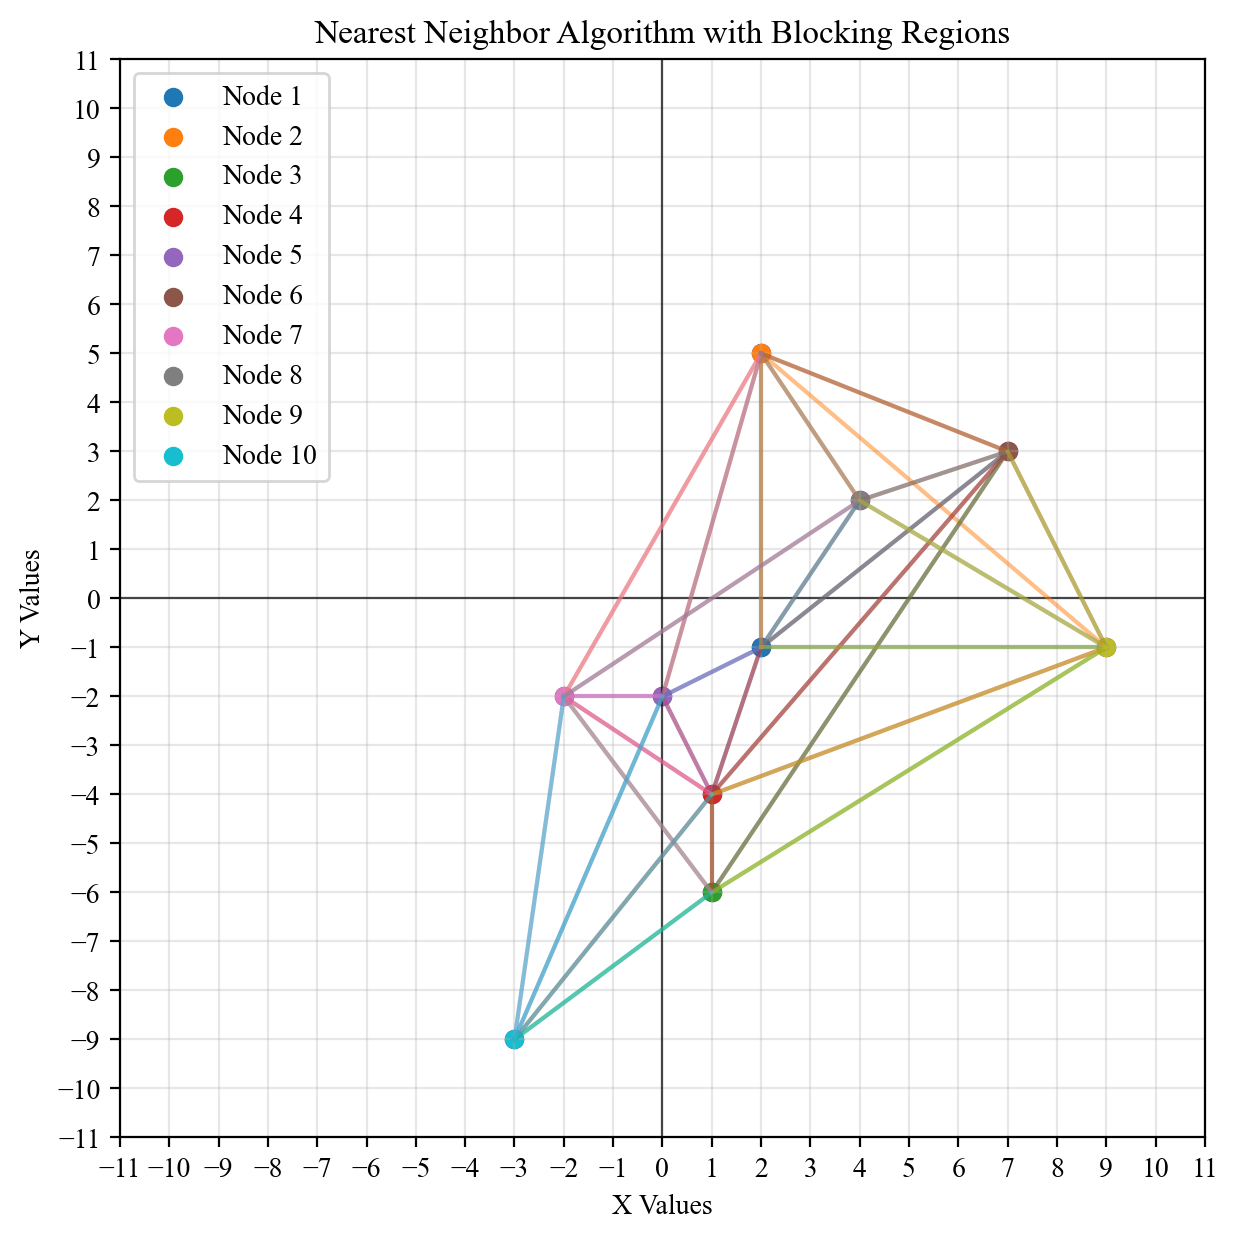

Neighbors of Node 1: [(0, -2), (1, -4), (4, 2), (2, 5), (7, 3), (9, -1)]


In [68]:
# --------------------------------------
# Data & Calculations
# --------------------------------------

# Parameters
dl = 2 # Width of a node (units)
arr_size, low_bound, high_bound,  = 10, -10, 10 # Increase arr_size for more nodes
# Create random data
x = np.random.randint(low=low_bound, high=high_bound, size=arr_size)
y = np.random.randint(low=low_bound, high=high_bound, size=arr_size)
# Keep original for later plotting
x_copy = x.copy()
y_copy = y.copy()
# Stacks the x and y coordinates into a 2D array
xy = np.column_stack((x, y))


# Store the neighbors of each node (following indices in x)
nodes_neighbors = [] 
# Loop through every node and find their respective neighbors
for nodes in xy:
    # Converts current node to a list
    node = nodes.tolist()
    # Get sorted distances and indices
    distances, indices = find_distances(node, x, y)
    # Sort x, y. Then removes first element (the node itself)
    x_temp, y_temp = x[indices], y[indices]
    x_temp, y_temp, distances = np.delete(x_temp, 0), np.delete(y_temp, 0), np.delete(distances, 0)
    # Get sorted thetas
    thetas = find_thetas(node, x_temp, y_temp)


    # !!! This part can be changed to use a different blocking algorithm !!!
    # Get the blocking portion, dx & dy of each neighbor nodes
    dx, dy = dl/2 * np.sin(thetas), dl/2 * np.cos(thetas)
    block1_x, block1_y = x_temp + dx, y_temp - dy
    block2_x, block2_y = x_temp - dx, y_temp + dy
    # Get the blocking portion in thetas
    block1_thetas, block2_thetas = find_thetas(node, block1_x, block1_y), find_thetas(node, block2_x, block2_y)
    # Converting thetas to 0 < θ < 2π
    thetas = np.where(thetas < 0, thetas + 2 * np.pi, thetas)
    block1_thetas = np.where(block1_thetas < 0, block1_thetas + 2 * np.pi, block1_thetas)
    block2_thetas = np.where(block2_thetas < 0, block2_thetas + 2 * np.pi, block2_thetas)
    # Correcting for θ1 = 350° and θ2 = 10°
    block2_thetas = np.where(block1_thetas > block2_thetas, block2_thetas + 2 * np.pi, block2_thetas)


    # Determines the indices of the nodes that are blocked
    all_blocked_indices = []
    for i in range(len(block1_thetas)):
        # Checks if ((θ1 < θ < θ2) | (θ1 < θ + 2π < θ2)) & (node distance > current node distance)
        blocked_indices = np.where((((thetas >= block1_thetas[i]) & (thetas <= block2_thetas[i])) |
                                    ((thetas + 2*np.pi >= block1_thetas[i]) & (thetas + 2*np.pi <= block2_thetas[i]))) &
                                    (distances > distances[i]))[0]

        all_blocked_indices.extend(blocked_indices)
            

    # Remove duplicate indices
    all_blocked_indices = np.unique(all_blocked_indices)
    x_temp = np.delete(x_temp, all_blocked_indices)
    y_temp = np.delete(y_temp, all_blocked_indices)
    
    # Appends the node and its neighbors to the list
    nodes_neighbors.append([x_temp, y_temp])
    

# --------------------------------------
# Graph Plotting
# --------------------------------------

from IPython.display import display, clear_output

# Create a scatter plot
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.scatter(x_copy, y_copy, color='purple')

plt.title('Nearest Neighbor Algorithm with Blocking Regions')
plt.xlabel('X Values')
plt.ylabel('Y Values')

# Axes configuration
ax.axvline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.7)
ax.set_xlim(low_bound - 1, high_bound + 1)
ax.set_ylim(low_bound - 1, high_bound + 1)
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=1))

ax.grid(True, alpha=0.3)

for i, node_neighbors in enumerate(nodes_neighbors):
    # Clear the previous output
    clear_output(wait=True)
    
    # Plot Scatter
    scatter_plot = ax.scatter(x[i], y[i], label=f'Node {i+1}')
    
    # Jargon for lines
    x_temp2, y_temp2 = np.full(node_neighbors[0].shape, x[i]), np.full(node_neighbors[1].shape, y[i])    
    current_color = scatter_plot.get_facecolor()[0]
    
    # Plot Lines
    ax.plot([x_temp2, node_neighbors[0]], [y_temp2, node_neighbors[1]], marker='None', color=current_color, alpha=0.5)
    
    # Updates the legend and fig
    plt.legend()
    display(fig)
    
    # Interactivity, breaks loop if user knows how to exit Vim
    user_input = input('Next Node? Press Any Key to Continue. To quit, exit Vim.')
    if user_input.lower() in [":q", ":wq", ":q!", ":x", ":qa", ":wqa", ":xall", "ZZ", "ZQ", ":exit"]:
        break

# Prevent duplicate plots
plt.savefig("../../reports/images/02_method_2_neighbors_2D.png", dpi=300)
plt.close()


# Checking
lis = [(int(x), int(y)) for x, y in zip(nodes_neighbors[0][0], nodes_neighbors[0][1])]
print(f'Neighbors of Node 1: {lis}')